### 4c, Model training for BI
- dataset will include outliers and engineered smart features
- category 'Unknown' is treated as it's own category for insight

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("df_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       895 non-null    float64
 1   Time_of_Day            894 non-null    object 
 2   Day_of_Week            901 non-null    object 
 3   Passenger_Count        899 non-null    float64
 4   Traffic_Conditions     895 non-null    object 
 5   Weather                898 non-null    object 
 6   Base_Fare              900 non-null    float64
 7   Per_Km_Rate            899 non-null    float64
 8   Per_Minute_Rate        895 non-null    float64
 9   Trip_Duration_Minutes  899 non-null    float64
 10  Trip_Price             942 non-null    float64
dtypes: float64(7), object(4)
memory usage: 81.1+ KB


In [4]:
# df_clean includes outliers, but missing data needs to be filled in accordingly
# the 2 datasets diverge at this point

df_filled = df.copy()
# Numerical fills:
cols_to_fill_mean = ["Base_Fare", "Per_Km_Rate", "Per_Minute_Rate"]
df_filled[cols_to_fill_mean] = df_filled[cols_to_fill_mean].fillna(df_filled[cols_to_fill_mean].mean())

cols_to_fill_median = ["Trip_Distance_km", "Trip_Duration_Minutes"]
df_filled[cols_to_fill_median] = df_filled[cols_to_fill_median].fillna(df_filled[cols_to_fill_median].median())

cols_to_fill_mode = ["Passenger_Count"]
df_filled[cols_to_fill_mode] = df_filled[cols_to_fill_mode].fillna(df_filled[cols_to_fill_mode].mode().iloc[0])

In [5]:
# Categorical fills:
cols_to_fill_unknown = ["Time_of_Day", "Day_of_Week", "Traffic_Conditions", "Weather"]
df_filled[cols_to_fill_unknown] = df_filled[cols_to_fill_unknown].fillna("Unknown")

In [6]:
df_filled.describe().T

,count,mean,std,min,25%,50%,75%,max
Trip_Distance_km,942.0,27.151454,19.694338,1.2300,13.082500,25.920000,37.907500,146.067047
Passenger_Count,942.0,2.498938,1.080943,1.0000,2.000000,3.000000,3.000000,4.000000
Base_Fare,942.0,3.494267,0.847760,2.0100,2.760000,3.494267,4.170000,5.000000
Per_Km_Rate,942.0,1.231313,0.419932,0.5000,0.870000,1.231313,1.580000,2.000000
Per_Minute_Rate,942.0,0.293765,0.112647,0.1000,0.200000,0.293765,0.390000,0.500000
Trip_Duration_Minutes,942.0,62.024342,31.566005,5.0100,36.635000,61.570000,87.887500,119.840000
Trip_Price,942.0,56.899296,40.594936,6.1269,33.739425,50.096200,68.994025,332.043689


In [7]:
# check what effect 'Unknown' has on Trip_Price with outliers included
# categorical features:
highest_cat_fares = df_filled.groupby(["Traffic_Conditions", "Time_of_Day", "Day_of_Week", "Weather"])["Trip_Price"].mean().reset_index().sort_values(by="Trip_Price", ascending=False)
highest_cat_fares[:20]

,Traffic_Conditions,Time_of_Day,Day_of_Week,Weather,Trip_Price
19,High,Morning,Weekday,Rain,127.806162
22,High,Morning,Weekend,Clear,123.704059
71,Low,Unknown,Weekday,Rain,120.337231
2,High,Afternoon,Weekday,Snow,117.976095
128,Unknown,Unknown,Weekend,Rain,110.254400
120,Unknown,Evening,Weekend,Clear,102.001100
43,Low,Afternoon,Weekend,Unknown,98.992673
104,Medium,Night,Weekday,Unknown,98.379600
118,Unknown,Evening,Weekday,Clear,97.057300
91,Medium,Evening,Weekend,Unknown,96.284500


In [8]:
#numerical
highest_num_fares = df_filled.groupby(["Trip_Distance_km", "Passenger_Count", "Base_Fare", "Per_Km_Rate", "Per_Minute_Rate", "Trip_Duration_Minutes"])["Trip_Price"].mean().reset_index().sort_values(by="Trip_Price", ascending=False)
highest_num_fares[:20]

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
937,138.763887,2.0,3.98,1.710000,0.390000,74.32,332.043689
922,100.380420,3.0,4.46,1.231313,0.293765,89.21,329.913004
935,130.809001,1.0,3.93,0.630000,0.160000,88.31,328.871769
929,109.616082,4.0,4.46,1.690000,0.230000,53.88,327.217665
940,145.747060,3.0,2.82,0.830000,0.490000,60.29,325.098950
927,107.786832,1.0,2.05,1.300000,0.180000,79.60,322.725996
941,146.067047,2.0,4.79,0.730000,0.300000,60.81,320.958664
939,139.476515,1.0,4.37,1.380000,0.200000,46.85,296.088697
923,101.039704,1.0,4.39,1.790000,0.293765,56.78,283.645201
936,138.098328,4.0,2.24,1.750000,0.320000,94.86,280.877302


In [9]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       942 non-null    float64
 1   Time_of_Day            942 non-null    object 
 2   Day_of_Week            942 non-null    object 
 3   Passenger_Count        942 non-null    float64
 4   Traffic_Conditions     942 non-null    object 
 5   Weather                942 non-null    object 
 6   Base_Fare              942 non-null    float64
 7   Per_Km_Rate            942 non-null    float64
 8   Per_Minute_Rate        942 non-null    float64
 9   Trip_Duration_Minutes  942 non-null    float64
 10  Trip_Price             942 non-null    float64
dtypes: float64(7), object(4)
memory usage: 81.1+ KB


In [10]:
# smart engineer categorical features accordingly:
# 'object' values in columns either into bools, ordinals or feature combination

#IsbusinessHour
df_filled["IsBusinessHour"] = (
    (df_filled["Weather"] == "Clear") &
    (df_filled["Day_of_Week"] == "Weekday") &
    (df_filled["Time_of_Day"].isin(["Morning", "Afternoon"])) & 
    (df_filled["Traffic_Conditions"].isin(["Low", "Medium", "High"]))
).astype(int)

In [11]:
# smart feature for weather Rainfall/snowfall. 'Clear' is implied. 'unknown' is its own category
df_filled["IsRain"] = (df_filled["Weather"] == "Rain").astype(int)
df_filled["IsSnow"] = (df_filled["Weather"] == "Snow").astype(int)
df_filled["IsWeatherUnknown"] = (df_filled["Weather"] == "Unknown").astype(int)

In [12]:
# smart feature to flag weekend (IsWeekend = 1)
df_filled["IsWeekend"] = (df_filled["Day_of_Week"] == "Weekend").astype(int)
df_filled["IsDayUnknown"] = (df_filled["Day_of_Week"] == "Unknown").astype(int)

In [13]:
# encode ordinals in traffic_condition to prep dataset for model training
df_filled["Traffic_Conditions_Num"] = pd.Categorical(
    df_filled["Traffic_Conditions"],
    categories=["Unknown", "Low", "Medium", "High"],
    ordered=True
).codes

In [14]:
# encode ordinals in time_of_day to prep dataset for model training
df_filled["Time_of_Day_Num"] = pd.Categorical(
    df_filled["Time_of_Day"],
    categories=["Unknown", "Morning", "Afternoon", "Evening", "Night"],
    ordered=True
).codes

In [15]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Trip_Distance_km        942 non-null    float64
 1   Time_of_Day             942 non-null    object 
 2   Day_of_Week             942 non-null    object 
 3   Passenger_Count         942 non-null    float64
 4   Traffic_Conditions      942 non-null    object 
 5   Weather                 942 non-null    object 
 6   Base_Fare               942 non-null    float64
 7   Per_Km_Rate             942 non-null    float64
 8   Per_Minute_Rate         942 non-null    float64
 9   Trip_Duration_Minutes   942 non-null    float64
 10  Trip_Price              942 non-null    float64
 11  IsBusinessHour          942 non-null    int64  
 12  IsRain                  942 non-null    int64  
 13  IsSnow                  942 non-null    int64  
 14  IsWeatherUnknown        942 non-null    in

In [23]:
# drop categorical features with 'object' value
df_BI_inc_outlier = df_filled.drop(columns=["Time_of_Day", "Day_of_Week", "Traffic_Conditions", "Weather"])
df_BI_inc_outlier.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Trip_Distance_km        942 non-null    float64
 1   Passenger_Count         942 non-null    float64
 2   Base_Fare               942 non-null    float64
 3   Per_Km_Rate             942 non-null    float64
 4   Per_Minute_Rate         942 non-null    float64
 5   Trip_Duration_Minutes   942 non-null    float64
 6   Trip_Price              942 non-null    float64
 7   IsBusinessHour          942 non-null    int64  
 8   IsRain                  942 non-null    int64  
 9   IsSnow                  942 non-null    int64  
 10  IsWeatherUnknown        942 non-null    int64  
 11  IsWeekend               942 non-null    int64  
 12  IsDayUnknown            942 non-null    int64  
 13  Traffic_Conditions_Num  942 non-null    int8   
 14  Time_of_Day_Num         942 non-null    in

### Curious to see what outliers do to dataset in model training

In [24]:
# split
# Features / target
X, y = df_BI_inc_outlier.drop(columns=["Trip_Price"]), df_BI_inc_outlier["Trip_Price"].astype(float)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score

In [27]:
# train/test on 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# train RF
rf = RandomForestRegressor(
    n_estimators=400, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,400
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# train shallow RF for BI
rf_shallow= rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=5,
    random_state=42, 
    n_jobs=-1
)
rf_shallow.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
#predict on shallow forest RF
pred_shallow = rf_shallow.predict(X_test)
mae = mean_absolute_error(y_test, pred_shallow)
rmse = root_mean_squared_error(y_test, pred_shallow)
r2 = r2_score(y_test, pred_shallow)
print({"mae": mae, "rmse": rmse, "r2": r2})

{'mae': 9.499500634770515, 'rmse': 13.302505187255617, 'r2': 0.9285075331929192}


In [29]:
# predict on deep forest RF
pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print({"mae": mae, "rmse": rmse, "r2": r2})

{'mae': 6.123813237473962, 'rmse': 10.46580303233852, 'r2': 0.9557474274735551}


In [32]:
# deep forest MAPE
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, pred)
print("MAPE:", round(mape*100, 2), "%")

MAPE: 13.04 %


In [36]:
# shallow forest MAPE
mape = mean_absolute_percentage_error(y_test, pred_shallow)
print("MAPE:", round(mape*100, 2), "%")

MAPE: 23.19 %


#### r2 is very high at 0.956 in deep forest which might mean model is overfitted

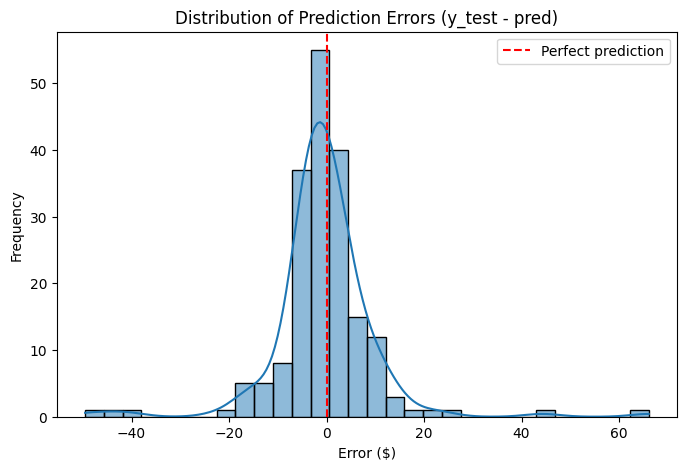

In [30]:
# histogram of error distribution
import matplotlib.pyplot as plt

errors = y_test - pred   # positive = model underpredicted, negative = overpredicted

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--", label="Perfect prediction")
plt.title("Distribution of Prediction Errors (y_test - pred)")
plt.xlabel("Error ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

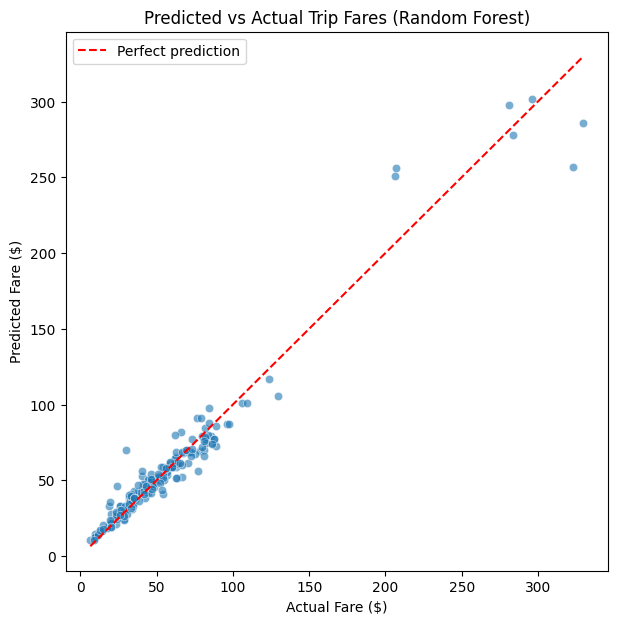

In [31]:
# scatterplot
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color="red", linestyle="--", label="Perfect prediction")

plt.xlabel("Actual Fare ($)")
plt.ylabel("Predicted Fare ($)")
plt.title("Predicted vs Actual Trip Fares (Random Forest)")
plt.legend()
plt.show()

In [ ]:
# export BI dataset for BI exploration
#df_BI.to_csv("df_BI.csv", index = False)

### Final conclusion:
- train prediction model on numeric features only for highest accuracy
- engineer BI dataset for insights incl outliers (but don't train model on it)
- use dataset cleaned of: 'unknown' (subsumed into 'closest' category)